# Hospital Operations Intelligence Platform

## Notebook 03: Feature Engineering

### Business objective

Transform cleaned operational records into reproducible, leakage-aware features
that machine learning models can use for readmission, waiting time, occupancy,
and revenue prediction.

### Feature groups

- Patient: age group, prior admissions, readmission history, complexity
- Clinical: severity and abnormal-lab scores
- Admission: LOS, weekend, season, emergency type
- Workforce: doctor experience and department load
- Financial: billing category, insurance, claim approval, revenue
- Capacity: medicine count, waiting time, and bed-utilization score

## 1. Imports and clean inputs

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
INTERIM = ROOT / "datasets" / "interim"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
EXPERIMENT_MODELS = MODELS / "experiments"
EXPERIMENT_REPORTS = REPORTS / "experiments"
for folder in [INTERIM, PROCESSED, MODELS, REPORTS, EXPERIMENT_MODELS, EXPERIMENT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from data_pipeline import engineer_features, link_billing_to_admissions
from train_models import CATEGORICAL_FEATURES, FEATURES

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
admissions = pd.read_csv(
    INTERIM / "admissions_clean.csv",
    parse_dates=["admit_date", "discharge_date"],
)
claims = pd.read_csv(
    INTERIM / "claims_clean.csv",
    parse_dates=["claim_billing_date"],
)
if "admission_id" not in claims:
    claims = link_billing_to_admissions(claims, admissions)

print("Clean admissions:", admissions.shape)
print("Clean claims:", claims.shape)

Clean admissions: (120000, 17)
Clean claims: (70000, 16)


## 2. Build operational features

In [3]:
final_dataset = engineer_features(admissions, claims)

feature_groups = {
    "patient": [
        "age", "age_group", "previous_admissions", "readmission_history",
        "patient_complexity_index", "risk_score",
    ],
    "admission": [
        "los_days", "is_weekend_admission", "admit_month", "season",
        "admit_type", "ward_type",
    ],
    "clinical": [
        "disease_severity_score", "lab_abnormality_score",
        "charlson_index", "hba1c", "creatinine", "haemoglobin",
    ],
    "workforce": ["doctor_id", "doctor_experience", "department_load"],
    "financial": [
        "insurance_category", "billing_category", "claim_approval_ratio",
        "revenue_per_patient", "average_medicine_cost",
    ],
    "capacity": [
        "medicine_count", "total_procedures", "average_waiting_time",
        "waiting_time_minutes", "bed_utilization_score",
    ],
}
for group, columns in feature_groups.items():
    print(group, "->", [column for column in columns if column in final_dataset])

display(final_dataset.head())

patient -> ['age', 'age_group', 'previous_admissions', 'readmission_history', 'patient_complexity_index', 'risk_score']
admission -> ['los_days', 'is_weekend_admission', 'admit_month', 'season', 'admit_type', 'ward_type']
clinical -> ['disease_severity_score', 'lab_abnormality_score', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin']
workforce -> ['doctor_id', 'doctor_experience', 'department_load']
financial -> ['insurance_category', 'billing_category', 'claim_approval_ratio', 'revenue_per_patient', 'average_medicine_cost']
capacity -> ['medicine_count', 'total_procedures', 'average_waiting_time', 'waiting_time_minutes', 'bed_utilization_score']


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,department,doctor_id,age,gender,medicine_code,medicine_count,admit_month,admit_dayofweek,is_weekend_admission,age_group,season,previous_admissions,readmission_history,department_daily_admissions,department_load,disease_severity_score,lab_abnormality_score,doctor_experience,bed_utilization_score,patient_complexity_index,risk_score,waiting_time_minutes,waiting_time_origin,average_waiting_time,total_procedures,billed_amount,paid_amount,claim_approval_ratio,claim_count,revenue_per_patient,revenue_origin,billing_category,insurance_category,average_medicine_cost,department_origin,doctor_origin,demographics_origin,medicine_origin
0,c144c705-46f0-41b5-8174-1f8548b77948,0000d640-e6fe-4842-9e26-7a81ea0ab158,2018-03-18,2018-03-30,12,Emergency,ICU,38925740-3bf1-4649-8b8b-ae114bf3677e,Expired,2,3,5.3,0.68,11.9,189,0,0,General Medicine,DOC021,19,Male,ATO,4,3,6,1,19-35,Spring,0,0,5,0.3125,7,1,26,0.468750,9,5.88125,60.0,simulated_formula,49.550141,2,12000.00,8640.00,0.72,0.0,8640.00,simulated_cost_formula,Very High,Self Pay,360.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
1,1ec05294-7bcf-4396-b3c1-d5ff3a414952,000179c6-8142-4fe3-9e9d-c9dbecc04185,2016-09-21,2016-09-30,9,Elective,HDU,72a121a0-e938-4373-8839-fc3a2a35fa6e,Recovered,2,2,6.7,0.89,12.0,104,0,0,General Medicine,DOC025,64,Male,ATO,3,9,2,0,51-65,Autumn,0,0,2,0.1250,4,0,17,0.140625,6,4.06250,33.0,simulated_formula,49.550141,2,9750.00,7020.00,0.72,0.0,7020.00,simulated_cost_formula,Very High,Self Pay,390.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
2,7eb1c804-e44c-4dea-958a-685068d9c302,0002f994-f6c6-42d6-bd4c-d417ef482fe7,2023-10-17,2023-10-20,3,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,0,0,6.1,0.80,11.9,135,0,0,Neurology,DOC020,26,Other,INS,1,10,1,0,19-35,Autumn,0,0,4,0.2500,0,0,25,0.093750,0,0.77500,43.0,simulated_formula,47.862839,0,215.32,144.69,1.00,1.0,144.69,surrogate_linked_claim,Low,Insurance,25.84,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
3,4fdf0ca2-3c32-4c20-a2cc-80f2d2d2a6ed,0003f6ac-7e58-4bbf-a1eb-ec61a99a734f,2018-07-22,2018-07-23,1,OPD,General,8b636965-b70d-4041-8c47-491d8a8a20f8,Recovered,0,0,5.6,1.00,12.7,161,1,0,Surgery,DOC038,32,Other,MET,1,7,6,1,19-35,Summer,0,0,7,0.4375,1,1,12,0.054688,1,0.74375,67.0,simulated_formula,50.803732,0,1550.00,1116.00,0.72,0.0,1116.00,simulated_cost_formula,Medium,Self Pay,186.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension
4,6405f675-83a3-4d14-9ab1-611de33564ff,0004ef9e-0300-4ceb-8fb4-336263602e71,2019-09-03,2019-09-06,3,Emergency,General,aac12881-4dea-42f3-bf32-8add9d5eee49,LAMA,1,0,6.1,0.96,12.1,131,1,0,Cardiology,DOC003,24,Female,MET,2,9,1,0,19-35,Autumn,0,0,8,0.5000,0,0,20,0.187500,1,1.10000,50.0,simulated_formula,49.950722,1,4050.00,2916.00,0.72,0.0,2916.00,simulated_cost_formula,High,Self Pay,243.00,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension,deterministic_derived_dimension


## 3. Validate engineered features

In [4]:
validation = pd.DataFrame(
    {
        "check": [
            "One row per admission",
            "No missing model features",
            "No first-visit history leakage",
            "Readmission target is binary",
            "Waiting time is non-negative",
            "Revenue is non-negative",
        ],
        "failures": [
            final_dataset.duplicated("admission_id").sum(),
            final_dataset[FEATURES].isna().sum().sum(),
            (
                (final_dataset["previous_admissions"] == 0)
                & (final_dataset["readmission_history"] != 0)
            ).sum(),
            (~final_dataset["readmitted_30d"].isin([0, 1])).sum(),
            (final_dataset["waiting_time_minutes"] < 0).sum(),
            (final_dataset["revenue_per_patient"] < 0).sum(),
        ],
    }
)
display(validation)
assert validation["failures"].sum() == 0

,check,failures
0,One row per admission,0
1,No missing model features,0
2,No first-visit history leakage,0
3,Readmission target is binary,0
4,Waiting time is non-negative,0
5,Revenue is non-negative,0


## 4. Encoding and scaling experiment

In [5]:
categorical = [column for column in CATEGORICAL_FEATURES if column in FEATURES]
numeric = [column for column in FEATURES if column not in categorical]

preprocessor = ColumnTransformer(
    [
        ("numeric", StandardScaler(), numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
    ]
)
sample = final_dataset[FEATURES].sample(min(5000, len(final_dataset)), random_state=42)
transformed = preprocessor.fit_transform(sample)

print("Raw model features:", sample.shape)
print("Encoded and scaled matrix:", transformed.shape)
print("Categorical levels are handled with unknown-category protection.")

Raw model features: (5000, 18)
Encoded and scaled matrix: (5000, 26)
Categorical levels are handled with unknown-category protection.


## 5. Feature visualizations

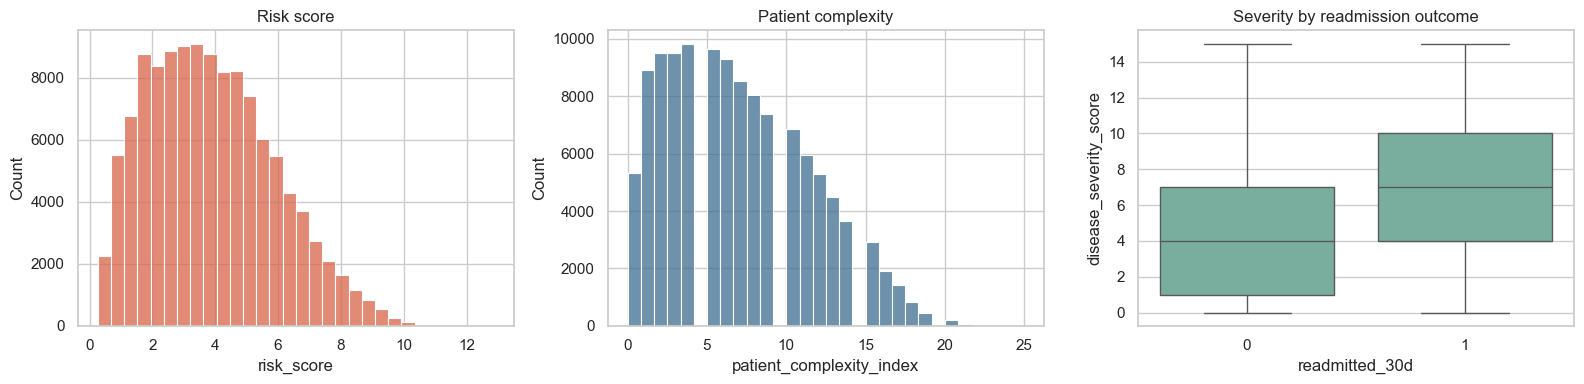

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(final_dataset["risk_score"], bins=30, ax=axes[0], color="#D7644A")
axes[0].set_title("Risk score")
sns.histplot(
    final_dataset["patient_complexity_index"],
    bins=30,
    ax=axes[1],
    color="#3D6E8F",
)
axes[1].set_title("Patient complexity")
sns.boxplot(
    data=final_dataset,
    x="readmitted_30d",
    y="disease_severity_score",
    ax=axes[2],
    color="#70B7A3",
)
axes[2].set_title("Severity by readmission outcome")
plt.tight_layout()
plt.show()

## 6. Save ML-ready data

In [7]:
final_dataset.to_csv(INTERIM / "notebook_model_features.csv", index=False)

feature_dictionary = pd.DataFrame(
    [
        {"feature_group": group, "feature": feature}
        for group, columns in feature_groups.items()
        for feature in columns
        if feature in final_dataset
    ]
)
feature_dictionary.to_csv(
    EXPERIMENT_REPORTS / "feature_dictionary.csv", index=False
)

print("Saved:", INTERIM / "notebook_model_features.csv")
print("Saved:", EXPERIMENT_REPORTS / "feature_dictionary.csv")

Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\datasets\interim\notebook_model_features.csv
Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\reports\experiments\feature_dictionary.csv


## Business conclusions

- Historical variables are calculated within patient groups to prevent cross-patient leakage.
- Encoders tolerate unseen categories in future Streamlit predictions.
- Scaling is fitted only inside model pipelines after the train/test split.
- Derived claim and demographic features remain explicitly documented because
  the raw files do not contain a governed natural relationship.

The ML-ready dataset is the input to Notebooks 04-07.